In [ ]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
from torch.utils.data import Subset


# Data

In [ ]:

training_data = datasets.MNIST(
    root="../data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.MNIST(
    root="../data",
    train=False,
    download=True,
    transform=ToTensor()
)

### Make dataset imbalanced

In [50]:
import torch
from collections import defaultdict

indices = []
thresshold = 5
amount = defaultdict(int)
targets = training_data.targets
for digit in range(10):
    digit_indices = (targets == digit).nonzero(as_tuple=True)[0]
    
    if digit < thresshold:
        selected = digit_indices[:len(digit_indices)//10]  # keep 10%
        amount["below"] += len(selected)
    else:
        selected = digit_indices[:len(digit_indices)//100]  # keep 1%
        amount["above"] += len(selected)
        
    print(f"For digit {digit} we select {len(selected)}")
    
    indices.append(selected)

indices = torch.cat(indices)

len(indices), amount

For digit 0 we select 592
For digit 1 we select 674
For digit 2 we select 595
For digit 3 we select 613
For digit 4 we select 584
For digit 5 we select 54
For digit 6 we select 59
For digit 7 we select 62
For digit 8 we select 58
For digit 9 we select 59


(3350, defaultdict(int, {'below': 3058, 'above': 292}))

In [53]:
subset_training_data = Subset(training_data, indices=indices)
len(subset_training_data)

3350

# Uncertainty sampling

In [ ]:
from sklearn.model_selection import ShuffleSplit

seed = 0
n_init = 20
n = len(subset_training_data)
sss = ShuffleSplit(n_splits=1, train_size=n_init / n, random_state=seed)
train, pool = next(sss.split(subset_training_data, subset_training_data.targets)) # sss is the indices 
test = test_data

data = dict(
    train = dict(
            X=X[train],
            y=y[train]
        ),
        pool = dict(
            X=X[pool[pool_]],
            y=y[pool[pool_]]
        ),
        test = dict(
            X=X[pool[test]],
            y=y[pool[test]]
        )
)

# Visualization 

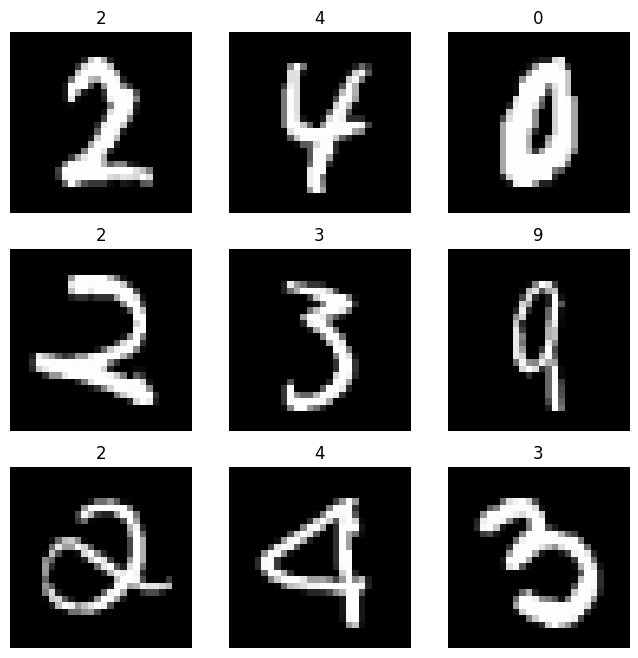

In [ ]:
labels_map = {
    0: "0",
    1: "1",
    2: "2",
    3: "3",
    4: "4",
    5: "5",
    6: "6",
    7: "7",
    8: "8",
    9: "9",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [5]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


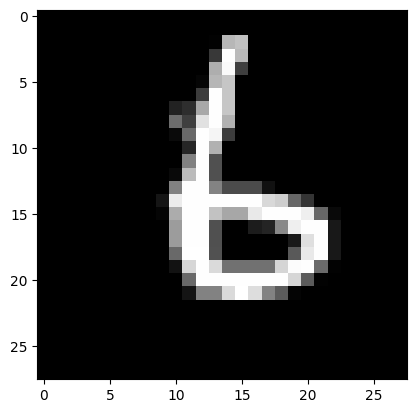

Label: 6


In [7]:
# Display image and label.
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")